In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance


In [4]:
df_2023 = pd.read_csv("/Users/nataliesgarcia/Desktop/dtsc4301/data/Delayed_Cancelled_Flights_2023sample.csv")
df_2024 = pd.read_csv("/Users/nataliesgarcia/Desktop/dtsc4301/data/Delayed_Cancelled_Flights_sample.csv")

df = pd.concat([df_2023, df_2024], ignore_index=True)

MODEL 1 - Can severe delays be predicting when booking? 
Including carrier, month, location, and date of flight
Potential can be predicted with seasonal patterns with date and carriers. 

In [5]:
df["SEVERE_DELAY"] = np.where(
    (df["DEP_DELAY"] > 60) | (df["CANCELLED"] == 1),
    1, 0
)
# Major hubs
major_hubs = ["ATL", "DFW", "ORD", "DEN", "LAX", "CLT", "LAS", "MCO", "LAX", "SEA", "LGA"]

df["HUB_ORIGIN"] = np.where(df["ORIGIN"].isin(major_hubs), 1, 0)

features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "MONTH",
    "DAY_OF_WEEK",
    "HUB_ORIGIN"
]

X = df[features]
y = df["SEVERE_DELAY"]

The following hubs were used as they are the top 10 hubs with the most delays/cancellations. Missing some major hubs as they weren't randomly selected to be in the sample as the smaple dataset is what we test and train. 

In [6]:
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"], format="mixed")
df["YEAR"] = df["FL_DATE"].dt.year

In [7]:
df["FL_DATE"].head()
df["YEAR"].value_counts()

YEAR
2023    10000
2024    10000
Name: count, dtype: int64

In [8]:
train_df = df[df["YEAR"] == 2023]
test_df  = df[df["YEAR"] == 2024]

X_train = train_df[features]
y_train = train_df["SEVERE_DELAY"]

X_test = test_df[features]
y_test = test_df["SEVERE_DELAY"]


Since we have data from 2023 and 2024 we want to take insights from both years. To avoid any leakage and overfitting as its best to use older data to train while evaluating "unseen" data. It helps avoid any random train-test splits as it's on a temporal split based on year data as data changes over time. It a way to learn from the past to aid the prediction of the future. 

In [9]:
print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 10000
Test size: 10000


Ensuring that Train and Test the same amount of data. 

In [10]:
print("Train class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train class distribution:
SEVERE_DELAY
0    0.6253
1    0.3747
Name: proportion, dtype: float64

Test class distribution:
SEVERE_DELAY
0    0.6129
1    0.3871
Name: proportion, dtype: float64


Ensuring the same distrubtion between the two classes. 

In [51]:
from sklearn.metrics import f1_score

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "MONTH",
    "DAY_OF_WEEK"
]

numeric_features = [
    "HUB_ORIGIN"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))

    results[name] = roc_auc_score(y_test, y_prob)


Logistic Regression
              precision    recall  f1-score   support

           0       0.62      0.88      0.73      6129
           1       0.46      0.16      0.24      3871

    accuracy                           0.60     10000
   macro avg       0.54      0.52      0.49     10000
weighted avg       0.56      0.60      0.54     10000

ROC AUC: 0.5607840749638393

Random Forest
              precision    recall  f1-score   support

           0       0.63      0.82      0.71      6129
           1       0.44      0.23      0.30      3871

    accuracy                           0.59     10000
   macro avg       0.53      0.52      0.51     10000
weighted avg       0.56      0.59      0.55     10000

ROC AUC: 0.5465043121159937

Gradient Boosting
              precision    recall  f1-score   support

           0       0.62      0.98      0.76      6129
           1       0.48      0.03      0.05      3871

    accuracy                           0.61     10000
   macro avg     

Above run logistic regression, random forest, and gradiant boosting model. Looking more at high roc auc and low recall for best perfomance. Reelvant high recall for delayed (61%).

In [49]:
from sklearn.metrics import f1_score

best_forecast_model_name = max(results, key=results.get)
print("Best Forecast Model:", best_forecast_model_name)

best_forecast_model = models[best_forecast_model_name]

best_forecast_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", best_forecast_model)
])

best_forecast_pipeline.fit(X_train, y_train)

Best Forecast Model: Gradient Boosting


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['OP_UNIQUE_CARRIER',
                                                   'ORIGIN', 'DEST', 'MONTH',
                                                   'DAY_OF_WEEK']),
                                                 ('num', 'passthrough',
                                                  ['HUB_ORIGIN'])])),
                ('classifier', GradientBoostingClassifier())])

Above choosing automaically best model rather than manually. 

In [47]:
df_test = test_df.copy()
df_test["predicted_delay_prob"] = best_pipeline.predict_proba(X_test)[:,1]

In [53]:
df_test["predicted_delay_prob"] = best_pipeline.predict_proba(X_test)[:,1]

worst_cases = df_test.sort_values("predicted_delay_prob", ascending=False).head(20)
best_cases = df_test.sort_values("predicted_delay_prob").head(20)

best_cases[["OP_UNIQUE_CARRIER","ORIGIN","MONTH","predicted_delay_prob"]]

,OP_UNIQUE_CARRIER,ORIGIN,MONTH,predicted_delay_prob
16898,WN,BNA,10,0.016667
18137,HA,OGG,6,0.018751
18116,WN,LAX,6,0.023333
14381,AS,SEA,6,0.026667
18551,WN,DAL,12,0.026667
13431,WN,LAS,7,0.029942
19909,WN,STL,10,0.033333
13261,AS,SEA,7,0.034525
10706,WN,LAS,6,0.036667
18717,WN,DEN,3,0.036667


Above shows the probability of very low severe delays flight (less than 60 min) showing patterns of southwest, alaska, hawaiian from orginis of the following above. Along with patterns in months of june, july, october, december, march. Find no heavy winter like jan/feb in th norther hubs which takes into account seasonal dirstuption patterns. Low probabilities due to 38% of flights are severe delayed. 

In [52]:
worst_cases[["OP_UNIQUE_CARRIER","ORIGIN","MONTH","predicted_delay_prob"]]

,OP_UNIQUE_CARRIER,ORIGIN,MONTH,predicted_delay_prob
12352,B6,DCA,7,0.928751
14435,B6,JAX,6,0.916667
19871,UA,SAN,6,0.913333
15945,NK,MCO,8,0.898183
12293,WN,MDW,1,0.896667
14080,OO,ASE,1,0.890000
10020,DL,JAX,4,0.890000
13990,DL,ATL,7,0.876667
12562,B6,MCO,3,0.873333
13199,UA,EWR,7,0.870000


Above shows worst case, high risk of severe delays. 

In [55]:
df_test.groupby("OP_UNIQUE_CARRIER")["predicted_delay_prob"].mean().sort_values()

OP_UNIQUE_CARRIER
HA    0.233645
AS    0.261352
WN    0.299429
G4    0.304253
MQ    0.315551
AA    0.381017
DL    0.387855
OH    0.388025
F9    0.404346
9E    0.421607
UA    0.422275
YX    0.425440
OO    0.427818
NK    0.434562
B6    0.485160
Name: predicted_delay_prob, dtype: float64

Above the lowest and highest probability of severe delay with carriers. 

In [54]:
hub_analysis = df_test.groupby("HUB_ORIGIN")["predicted_delay_prob"].mean()

print("Average Predicted Delay Probability")
print(hub_analysis)

Average Predicted Delay Probability
HUB_ORIGIN
0    0.374245
1    0.374912
Name: predicted_delay_prob, dtype: float64


Above shows that there is no difference between non-hub and hub severe delay probability. Indicating that hub traffic doesn't result to severe delay risk and delay can escalation at any hub. 

Confusion Matrix:
[[2027 4102]
 [ 953 2918]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.33      0.45      6129
           1       0.42      0.75      0.54      3871

    accuracy                           0.49     10000
   macro avg       0.55      0.54      0.49     10000
weighted avg       0.58      0.49      0.48     10000



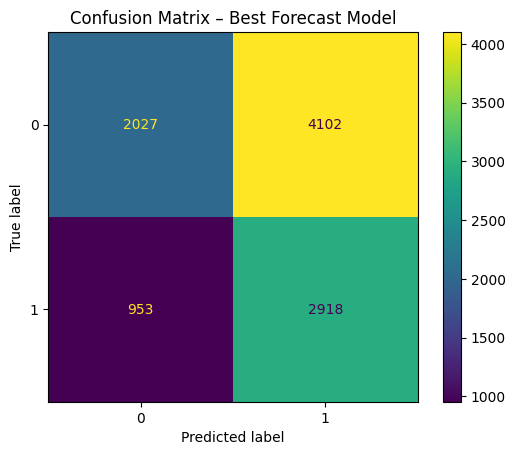

In [65]:
y_prob_best = best_forecast_pipeline.predict_proba(X_test)[:, 1]

# Choose threshold
threshold = 0.35  # You can experiment with 0.30–0.40

y_pred_best = (y_prob_best > threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_best)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix – Best Forecast Model")
plt.show()

In [58]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
SEVERE_DELAY
0    0.6253
1    0.3747
Name: proportion, dtype: float64

Test distribution:
SEVERE_DELAY
0    0.6129
1    0.3871
Name: proportion, dtype: float64


In [60]:
print(">15 min:", (df["DEP_DELAY"] > 15).mean())
print(">30 min:", (df["DEP_DELAY"] > 30).mean())
print(">60 min:", (df["DEP_DELAY"] > 60).mean())
print(">120 min:", (df["DEP_DELAY"] > 120).mean())

>15 min: 0.73855
>30 min: 0.5797
>60 min: 0.31915
>120 min: 0.12585


In [69]:
rf_model = best_pipeline.named_steps["classifier"]

feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
0,cat__OP_UNIQUE_CARRIER_9E,0.0
389,cat__DEST_FWA,0.0
391,cat__DEST_GEG,0.0
392,cat__DEST_GFK,0.0
393,cat__DEST_GGG,0.0
394,cat__DEST_GJT,0.0
395,cat__DEST_GNV,0.0
396,cat__DEST_GPT,0.0
397,cat__DEST_GRB,0.0
398,cat__DEST_GRI,0.0


In [79]:
feature_names = X_test_op.columns

Below, Given operational conditions, what drives severe delay escalation?

In [39]:
df["WEATHER_FLAG"] = (df["WEATHER_DELAY"] > 0).astype(int)
df["NAS_FLAG"] = (df["NAS_DELAY"] > 0).astype(int)
df["CARRIER_FLAG"] = (df["CARRIER_DELAY"] > 0).astype(int)
df["SECURITY_FLAG"] = (df["SECURITY_DELAY"] > 0).astype(int)
df["LATE_AIRCRAFT_FLAG"] = (df["LATE_AIRCRAFT_DELAY"] > 0).astype(int)

In [70]:
operational_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "MONTH",
    "DAY_OF_WEEK",
    "HUB_ORIGIN",
    "WEATHER_FLAG",
    "NAS_FLAG",
    "CARRIER_FLAG",
    "SECURITY_FLAG",
    "LATE_AIRCRAFT_FLAG"
]

In [41]:
train_df = df[df["YEAR"] == 2023]
test_df  = df[df["YEAR"] == 2024]

X_train_op = train_df[operational_features]
y_train_op = train_df["SEVERE_DELAY"]

X_test_op = test_df[operational_features]
y_test_op = test_df["SEVERE_DELAY"]

In [71]:
categorical_features_op = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "MONTH",
    "DAY_OF_WEEK"
]

numeric_features_op = [
    "HUB_ORIGIN",
    "WEATHER_FLAG",
    "NAS_FLAG",
    "CARRIER_FLAG",
    "SECURITY_FLAG",
    "LATE_AIRCRAFT_FLAG"
]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_op = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_op),
        ("num", "passthrough", numeric_features_op)
    ]
)

In [81]:
operational_models = {
    "Logistic Regression (Operational)": LogisticRegression(max_iter=1000),

    "Balanced Random Forest (Operational)": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting (Operational)": GradientBoostingClassifier()
}

op_results = {}

for name, model in operational_models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_op),
        ("classifier", model)
    ])

    pipeline.fit(X_train_op, y_train_op)

    y_pred = pipeline.predict(X_test_op)
    y_prob = pipeline.predict_proba(X_test_op)[:,1]

    print(f"\n{name}")
    print(classification_report(y_test_op, y_pred))
    print("ROC AUC:", roc_auc_score(y_test_op, y_prob))

    op_results[name] = roc_auc_score(y_test_op, y_prob)


Logistic Regression (Operational)
              precision    recall  f1-score   support

           0       0.68      0.82      0.75      6129
           1       0.59      0.40      0.47      3871

    accuracy                           0.66     10000
   macro avg       0.64      0.61      0.61     10000
weighted avg       0.65      0.66      0.64     10000

ROC AUC: 0.6776258896651469

Balanced Random Forest (Operational)
              precision    recall  f1-score   support

           0       0.70      0.83      0.76      6129
           1       0.62      0.43      0.51      3871

    accuracy                           0.68     10000
   macro avg       0.66      0.63      0.64     10000
weighted avg       0.67      0.68      0.66     10000

ROC AUC: 0.7107812151546368

Gradient Boosting (Operational)
              precision    recall  f1-score   support

           0       0.69      0.89      0.78      6129
           1       0.67      0.37      0.48      3871

    accuracy        

In [73]:
best_operational_model_name = max(op_results, key=op_results.get)
print("Best Operational Model:", best_operational_model_name)

best_operational_model = operational_models[best_operational_model_name]

best_operational_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_op),
    ("classifier", best_operational_model)
])

best_operational_pipeline.fit(X_train_op, y_train_op)

Best Operational Model: Gradient Boosting (Operational)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['OP_UNIQUE_CARRIER',
                                                   'ORIGIN', 'DEST', 'MONTH',
                                                   'DAY_OF_WEEK']),
                                                 ('num', 'passthrough',
                                                  ['HUB_ORIGIN', 'WEATHER_FLAG',
                                                   'NAS_FLAG', 'CARRIER_FLAG',
                                                   'SECURITY_FLAG',
                                                   'LATE_AIRCRAFT_FLAG'])])),
                ('classifier', GradientBoostingClassifier())])

In [44]:
print("\n=== Forecast Model AUCs ===")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

print("\n=== Operational Model AUCs ===")
for model, score in op_results.items():
    print(f"{model}: {score:.4f}")


=== Forecast Model AUCs ===
Logistic Regression: 0.5608
Balanced Random Forest: 0.5459
Gradient Boosting: 0.5638

=== Operational Model AUCs ===
Logistic Regression (Operational): 0.6776
Balanced Random Forest (Operational): 0.7108
Gradient Boosting (Operational): 0.7267


In [74]:
gb_model = best_op_pipeline.named_steps["classifier"]

feature_names = best_op_pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_importance_op = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance_op.head(20)

,Feature,Importance
593,num__NAS_FLAG,0.077629
594,num__CARRIER_FLAG,0.031723
596,num__LATE_AIRCRAFT_FLAG,0.029196
584,cat__DAY_OF_WEEK_1,0.015569
590,cat__DAY_OF_WEEK_7,0.015463
588,cat__DAY_OF_WEEK_5,0.015440
587,cat__DAY_OF_WEEK_4,0.015260
586,cat__DAY_OF_WEEK_3,0.014163
585,cat__DAY_OF_WEEK_2,0.013916
589,cat__DAY_OF_WEEK_6,0.013865


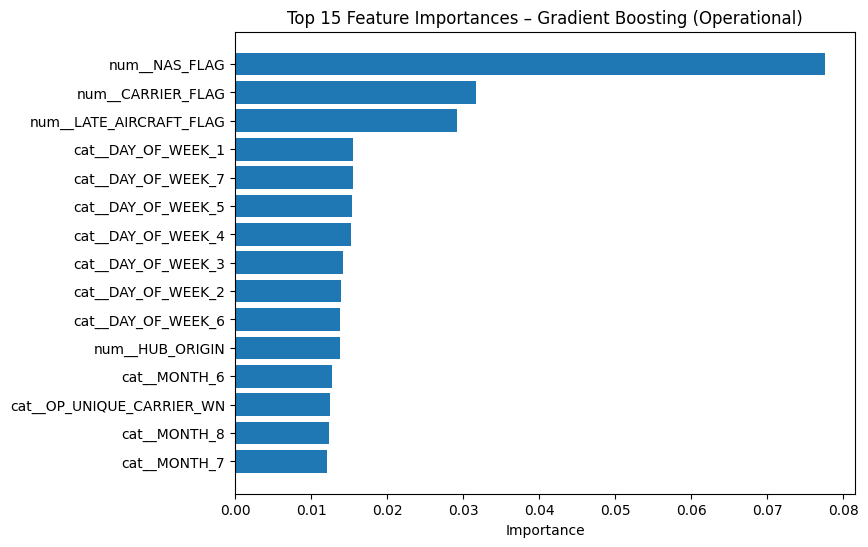

In [75]:
top_features = feature_importance_op.head(15)
plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances – Gradient Boosting (Operational)")
plt.xlabel("Importance")
plt.show()

In [77]:
feature_names = X_test_op.columns

In [ ]:
result = permutation_importance(
    best_op_pipeline,
    X_test_op,
    y_test_op,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_importance = pd.DataFrame({
    "Feature": X_test_op.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

perm_importance.head(20)

,Feature,Importance
7,NAS_FLAG,0.159985
10,LATE_AIRCRAFT_FLAG,0.046728
8,CARRIER_FLAG,0.035655
0,OP_UNIQUE_CARRIER,0.021699
3,MONTH,0.005546
6,WEATHER_FLAG,0.004120
9,SECURITY_FLAG,0.000631
2,DEST,-0.000009
1,ORIGIN,-0.000590
4,DAY_OF_WEEK,-0.000750
